## Part I: Applying Image Processing Filters For Image Cartoonifying

### Objective
In this part of the assignment, the objective is to process real-world images to make them look like they are genuinely from a cartoon. The fundamental approach is to smooth the flat regions of the image with a solid color, and then draw thick, distinct lines over the strong edges. To achieve this comic book effect, we will detect edges, smooth the image, and overlay the enhanced edges back on top.

### 1.1 Generating a Black-and-White Sketch 

To obtain a sketch (black-and-white drawing) of the image, we will utilize an edge-detection filter. However, edge detection is highly sensitive to noise. 

#### 1.1.1 Noise Reduction Using Median Filter 
We need to reduce the noise in the image before we use a Laplacian edge filter. We accomplish this using a Median filter, which is highly effective at removing noise while keeping the edges sharp. 

Because Laplacian filters operate on grayscale images, we must first convert the original image from OpenCV's default BGR color space to Grayscale. 
* **Grayscale Conversion:** The conversion applies weights to the color channels based on human perception:
  $$Y = 0.299R + 0.587G + 0.114B$$
* **Median Filtering:** A spatial filter slides a kernel (e.g., $5 \times 5$) across the image matrix. For each position, it sorts all the pixel values within the window and replaces the central pixel with the median value. Then, for noise reduction, we apply the Median filter.

In [2]:
!pip install opencv-python numpy matplotlib

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 3.6 MB/s eta 0:00:11
   - -------------------------------------- 1.8/40.2 MB 3.5 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/40.2 MB 3.5 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/40.2 MB 3.5 MB/s eta 0:00:11
   ---- ----------------------------------- 4.2/40.2 MB 3.5 MB/s eta 0:00:11
   ---- ----------------------------------- 4.7/40.2 MB 3.5 MB/s eta 0:00:11
   ----- ---------------------------------- 5.5/40.2 MB 3.5 MB/s eta 0:00:10
   ------ --------------------------------- 6.3/40.2 MB 3.5 MB/s eta 0:00:10
   ------ --------------------------------- 6.3/40.2 MB 3.5 MB/s eta 0:00:10
   ------- -------------------------------- 7.9/40.2 MB 3.6 MB/s eta 0:00:10
   -------- ------------------------------- 8.4/40.2 MB 3.5 MB/s eta 0:00:09
   --------- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.13.0 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


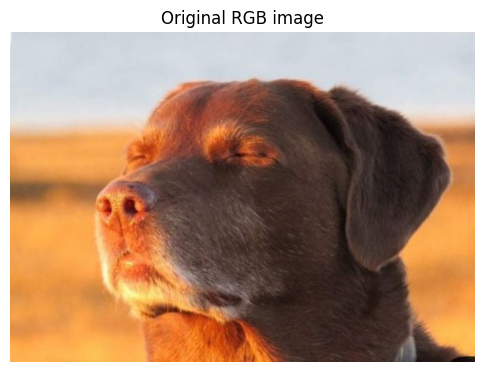

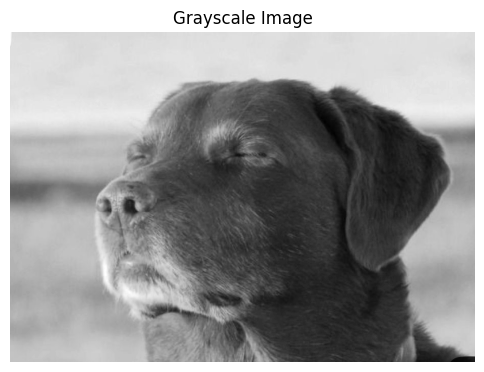

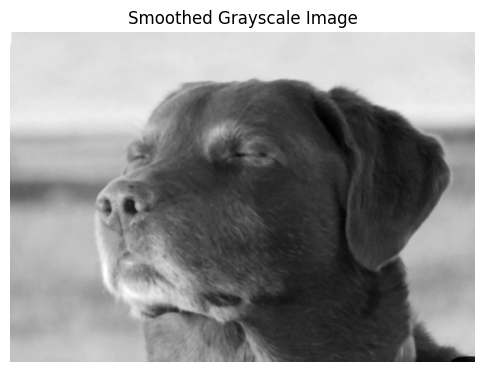

In [4]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, image, is_gray=False):
    plt.figure(figsize=(6, 6))
    if is_gray:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

image_path = 'assets/its_over.jpg' 
original_image = cv2.imread(image_path)

if original_image is None:
    print("Error: Could not load image.")
else:
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    
    smoothed_image = cv2.medianBlur(gray_image, 5)

    show_image("Original RGB image", original_image)
    show_image("Grayscale Image", gray_image, is_gray=True)
    show_image("Smoothed Grayscale Image", smoothed_image, is_gray=True)

### 1.1.2 Edge Detection Using Laplacian Filter

After noise reduction, a Laplacian filter is used for edge detection. The Laplacian operator is a second-order derivative mask that calculates the divergence of the gradient in an image, perfectly highlighting regions of rapid intensity change (the edges).

$$\Delta f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$


The Laplacian filter produces edges with varying brightness. Therefore, to make the edges look more like a sketch we apply a binary threshold to make the edges either white or black. 

By default, edge detection produces white lines on a black background. Since a real sketch is black ink on white paper, we will use an inverted binary threshold (`cv2.THRESH_BINARY_INV`).

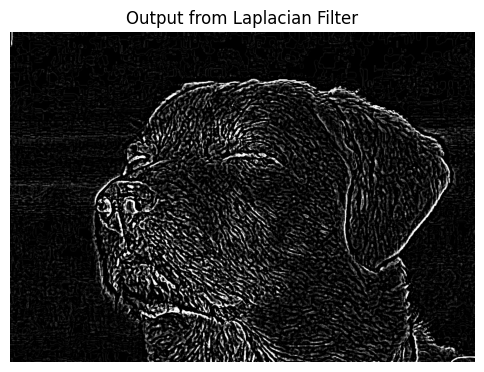

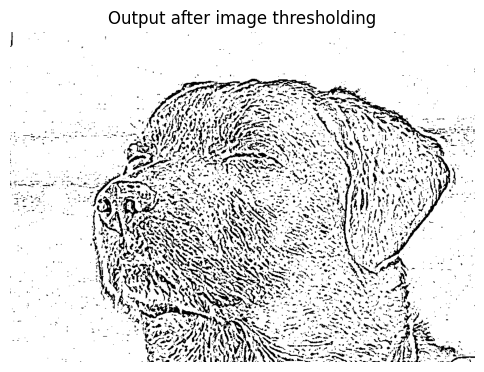

In [11]:
laplacian_edges = cv2.Laplacian(smoothed_image, cv2.CV_8U, ksize=5)

threshold_value = 50
_, sketch_mask = cv2.threshold(laplacian_edges, threshold_value, 255, cv2.THRESH_BINARY_INV)

show_image("Output from Laplacian Filter", laplacian_edges, is_gray=True)
show_image("Output after image thresholding", sketch_mask, is_gray=True)

### 1.2 Generating a Color Painting and a Cartoon

To obtain the color painting effect, we apply an edge-preserving filter known as the **Bilateral Filter**. A standard Gaussian blur smooths everything indiscriminately by averaging nearby pixels. A bilateral filter is smarter: it uses two separate Gaussian distributions.
1.  **Spatial Gaussian:** Weights pixels based on physical distance (closer pixels have more influence).
2.  **Intensity/Color Gaussian:** Weights pixels based on color similarity (only pixels with similar colors have influence).

The mathematical formulation for a pixel $\mathbf{p}$ is:
$$BF[I]_{\mathbf{p}} = \frac{1}{W_{\mathbf{p}}} \sum_{\mathbf{q} \in S} G_{\sigma_s}(\|\mathbf{p} - \mathbf{q}\|) G_{\sigma_r}(|I_{\mathbf{p}} - I_{\mathbf{q}}|) I_{\mathbf{q}}$$

This combination smooths flat regions while keeping edges sharp. However, a strong bilateral filter is computationally expensive and extremely slow. 

To optimize this, instead of applying one massive filter (e.g., $21 \times 21$), we apply many small bilateral filters (e.g., $9 \times 9$) multiple times. This produces a strong cartoon effect in significantly less time. 

Finally, to create the cartoon, we overlay the edge mask "sketch" onto the bilateral filter "painting". We use a bitwise AND operation, which essentially starts with a black background and copies the "painting" pixels that aren't edges in the "sketch" mask.

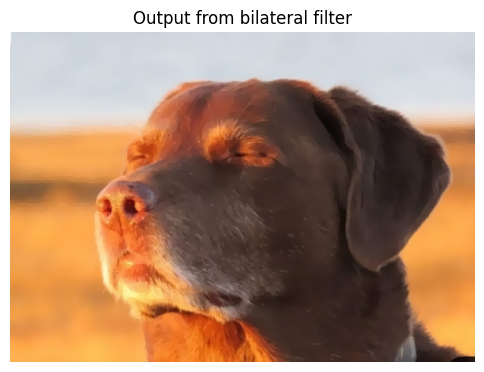

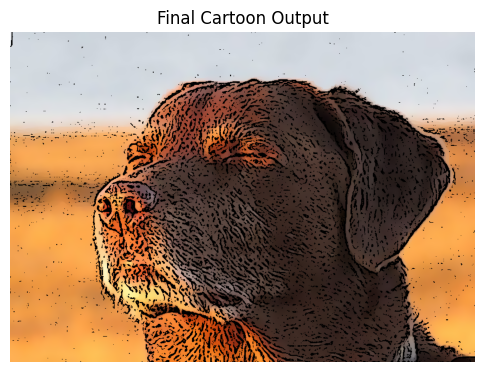

In [12]:
num_repetitions = 7
ksize = 9 # filter size 
sigma_color = 9 # affects how much the colors are mixed together. Higher means more mixing
sigma_space = 7 # determines how much neighboring pixels influence each other

color_painting = original_image.copy()

for _ in range(num_repetitions):
    color_painting = cv2.bilateralFilter(color_painting, ksize, sigma_color, sigma_space)

final_cartoon = cv2.bitwise_and(color_painting, color_painting, mask=sketch_mask)

show_image("Output from bilateral filter", color_painting)
show_image("Final Cartoon Output", final_cartoon)